# 나를 찾아줘 - Class Activation Map 만들기 [프로젝트]

## 목표 : CAM 과 grad CAM을 구현해보자++

* 사전학습된 resnet50 을 가지고 stanford_dogs 데이터를 추가 학습하여, 더 빨리 더 높은 정확도를 가진 모델을 구한다.
* 구한 모델을 통해, 개가 나온 사진에 히트맵으로 표현하고 이를 bbox로 만들어 정답지인 box와 비교해본다
* 비교 방식은 IOU (교집합 영역/합집합 영역) 방식을 사용한다.
아래 소스는 모든 소스가 아니고, 데이터 다운로드 소스등 두번 시행할 필요가 없는 소스는 제외되었습니다.
혹시 데이터가 없는 상태에서 실행을 할 경우 cam-gradcam.ipynb 파일을 참고하여 시행하시면 됩니다.


In [2]:
!pip install opencv-python
!pip install torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 93.2 MB/s eta 0:00:00:00:0100:01


In [3]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F
from torchinfo import summary

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [37]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

In [5]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [ymin, xmin, ymax, xmax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 경로 (재구성한 ImageFolder 형식)
train_dir = os.path.join('stanford_dogs', 'train')
test_dir = os.path.join('stanford_dogs', 'test')
# Annotation 폴더 경로 (예: '/root/Annotation')
annotation_dir = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Annotation')

# 커스텀 데이터셋 생성: image, label, bbox 반환
train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


In [7]:
def visualize(sample):
    img_tensor, label, bbox = sample

    # 인덱스와 클래스 정보
    print("Label index:", label)
    print("Class name:", train_dataset.classes[label])

    # 정규화 복원 전처리 시 사용한 평균과 표준편차
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # tensor의 shape: (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.title(f"Class: {train_dataset.classes[label]}")
    plt.axis('off')
    plt.show()

Label index: 0
Class name: n02085620-Chihuahua


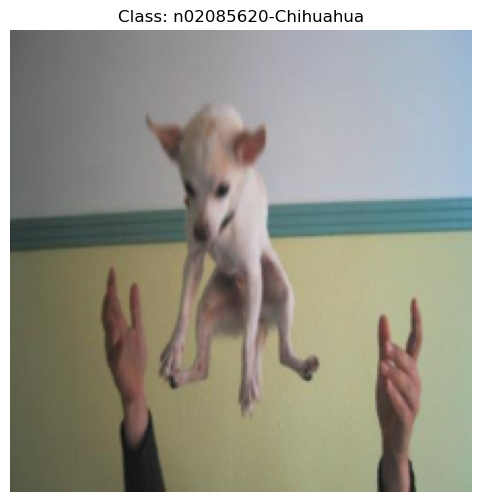

In [8]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
train_sample = train_dataset[0]

visualize(train_sample)

In [9]:
# Annotation 폴더에서 데이터를 골라보세요
annotation_path = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Annotation/n02085620-Chihuahua/n02085620_10074')


# XML 파일 파싱
tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")

annotation: 
	
folder: 02085620
filename: n02085620_10074
source: 
		
database: ImageNet database
size: 
		
width: 333
height: 500
depth: 3
segment: 0
object: 
		
name: Chihuahua
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 25
ymin: 10
xmax: 276
ymax: 498


In [19]:
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
summary(model)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─Bottleneck: 2-1                   --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─Bottleneck: 2-2                   --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12            128
│    │    └─Conv2d: 3-13               

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [22]:
from torch.utils.data import TensorDataset, DataLoader, random_split
import copy

def train_val_accs_visualization(train_accs, val_accs, epochs=20):
    epochs_range = range(1, epochs + 1)

    if len(train_accs) < epochs:
        for i in range(epochs - len(train_accs)):
            train_accs.append(train_accs[-1])

    if len(val_accs) < epochs:
        for i in range(epochs - len(val_accs)):
            val_accs.append(val_accs[-1])

    plt.clf()

    plt.plot(epochs_range, train_accs, 'bo', label='Training accuracy')
    plt.plot(epochs_range, val_accs, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

def train_val_loss_visualization(train_losses, val_losses, epochs=20):
    epochs_range = range(1, epochs + 1)

    if len(train_losses) < epochs:
        for i in range(epochs - len(train_losses)):
            train_losses.append(train_losses[-1])

    if len(val_losses) < epochs:
        for i in range(epochs - len(val_losses)):
            val_losses.append(val_losses[-1])

    plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
    plt.plot(epochs_range, val_losses, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

        # 검증 단계
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        test_loss = running_loss / len(valid_loader)
        test_acc = correct / total
        val_losses.append(test_loss)
        val_accs.append(test_acc)
        print(f"Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")
    train_val_loss_visualization(train_losses, val_losses, epochs=num_epochs)
    train_val_accs_visualization(train_accs, val_accs, epochs=num_epochs)
    return model


Epoch 1/7 시작
  Step 50 - Loss: 3.7797
  Step 100 - Loss: 3.6883
  Step 150 - Loss: 4.3182
  Step 200 - Loss: 3.9552
  Step 250 - Loss: 3.3677
  Step 300 - Loss: 2.4947
  Step 350 - Loss: 3.1810
  Step 400 - Loss: 3.6027
  Step 450 - Loss: 2.3559
  Step 500 - Loss: 2.7367
  Step 550 - Loss: 3.3214
  Step 600 - Loss: 2.3717
  Step 650 - Loss: 3.4769
  Step 700 - Loss: 4.0183
  Step 750 - Loss: 3.9120
  Step 800 - Loss: 2.6917
  Step 850 - Loss: 3.6360
  Step 900 - Loss: 2.9801
  Step 950 - Loss: 2.2452
  Step 1000 - Loss: 2.8802
Train - Loss: 3.2097, Accuracy: 22.56%
Validation - Loss: 2.7455, Accuracy: 29.56%

Epoch 2/7 시작
  Step 50 - Loss: 3.1181
  Step 100 - Loss: 2.2932
  Step 150 - Loss: 2.9584
  Step 200 - Loss: 2.8962
  Step 250 - Loss: 2.2932
  Step 300 - Loss: 2.0522
  Step 350 - Loss: 1.6766
  Step 400 - Loss: 2.4093
  Step 450 - Loss: 2.3339
  Step 500 - Loss: 2.9871
  Step 550 - Loss: 2.6994
  Step 600 - Loss: 1.2484
  Step 650 - Loss: 2.8718
  Step 700 - Loss: 3.0737
  Step

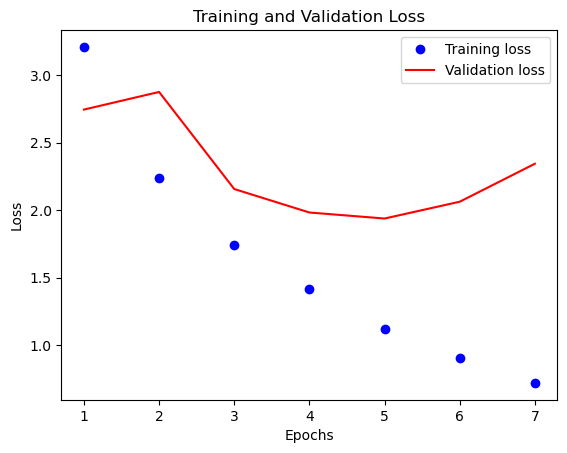

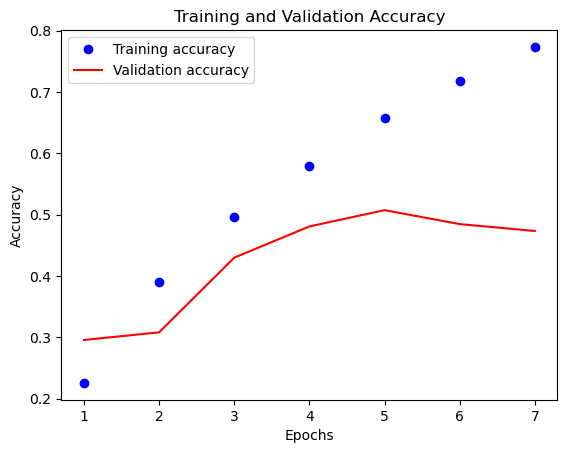

CPU times: user 17min 48s, sys: 35.3 s, total: 18min 23s
Wall time: 18min 44s


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [23]:
%%time

train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=7)

In [24]:
# Q. '/work/class_activation_map' 에 'cam_model1.h5'을 저장하세요.

cam_model_path = os.path.join(os.getenv("HOME"), "work/class_activation_map/cam_model_haji.pt")

torch.save(model, cam_model_path)

In [25]:
# 원하는 데이터를 골라서 진행해보세요

image, label, bbox = train_dataset[0]
sample_image = image.unsqueeze(0).to(device)

In [26]:
cam_model_path = os.path.join(os.getenv("HOME"), "work/class_activation_map/cam_model_haji.pt")

In [27]:
# 모델을 불러오세요

# [[YOUR CODE]]
model = torch.load(cam_model_path, weights_only=False)

In [28]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [29]:
cam = generate_cam(model, sample_image)

In [30]:
def visualize_cam(cam):
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title("CAM")
    plt.axis('off')
    plt.show()

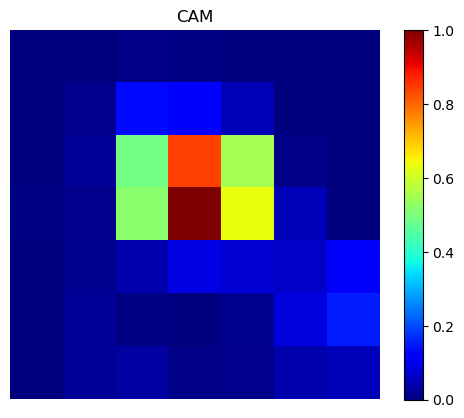

In [31]:
visualize_cam(cam)

In [ ]:
def visualize_cam_on_image_2(cam, img, alpha=0.5):

    blended_img = cv2.addWeighted(cam, alpha, img, 1 - alpha, 0)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

In [ ]:
visualize_cam_on_image_2(cam_image, sample_image,0.3)

In [35]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)
    
#    blended_img = cv2.addWeighted(cam, alpha, img, 1 - alpha, 0)


    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

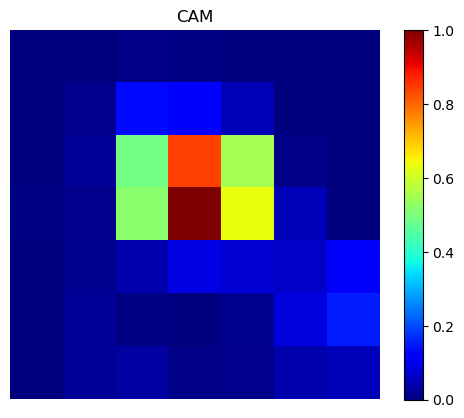

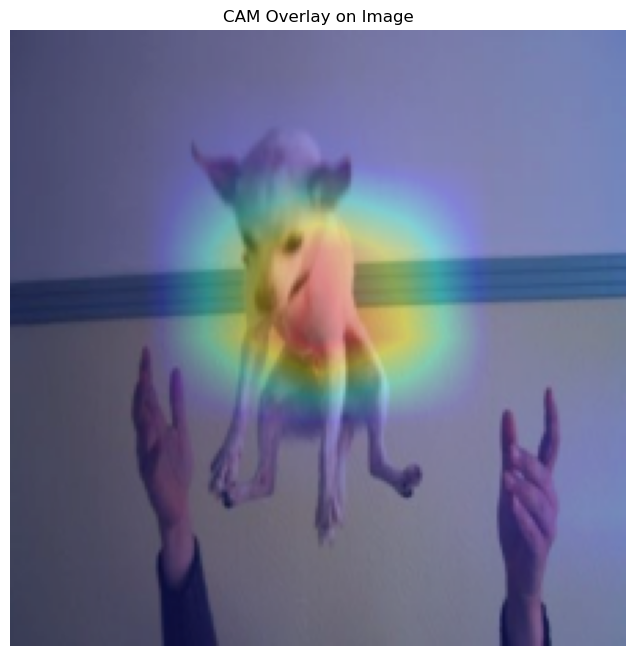

In [38]:
# 원본 이미지 복원
orig_img = unnormalize(image)

# CAM 단독 시각화
visualize_cam(cam)

# 원본 이미지 위에 CAM overlay 시각화
visualize_cam_on_image(cam, orig_img,0.3)

In [39]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

/opt/conda/lib/python3.12/site-packages/torch/nn/modules/module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


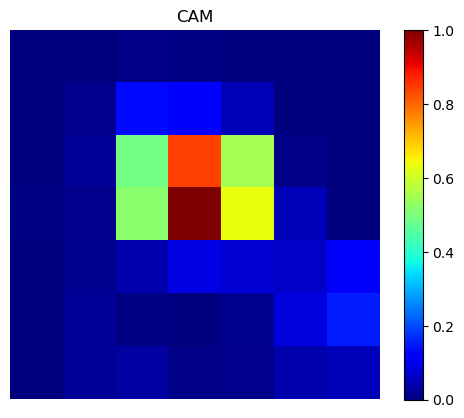

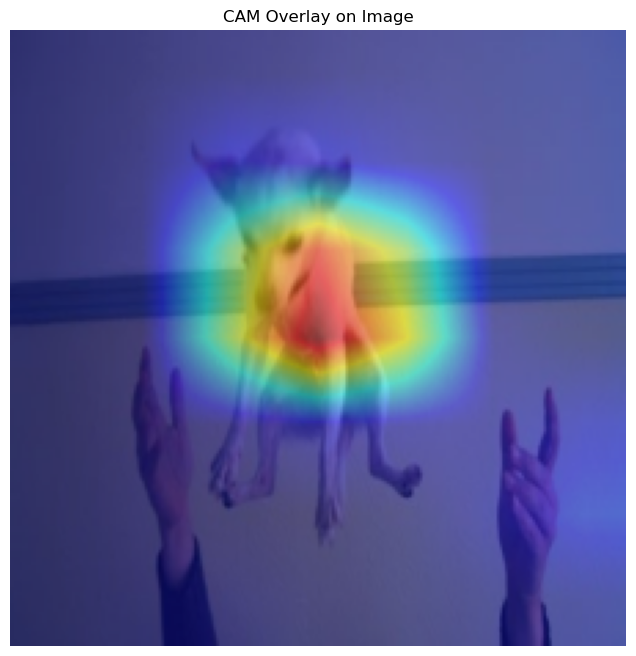

In [40]:
# layer4 사용
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

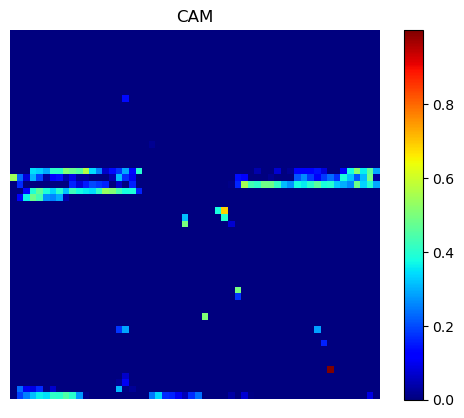

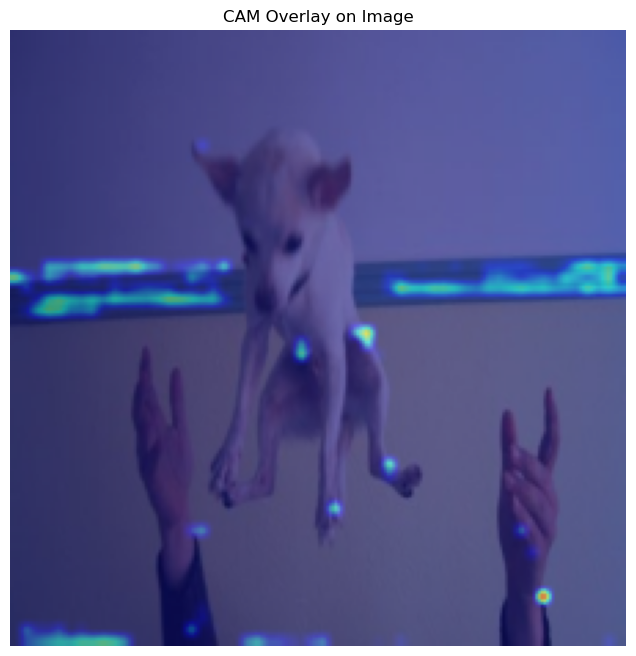

In [41]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer1")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

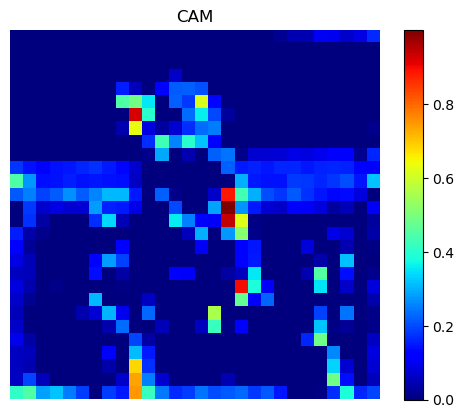

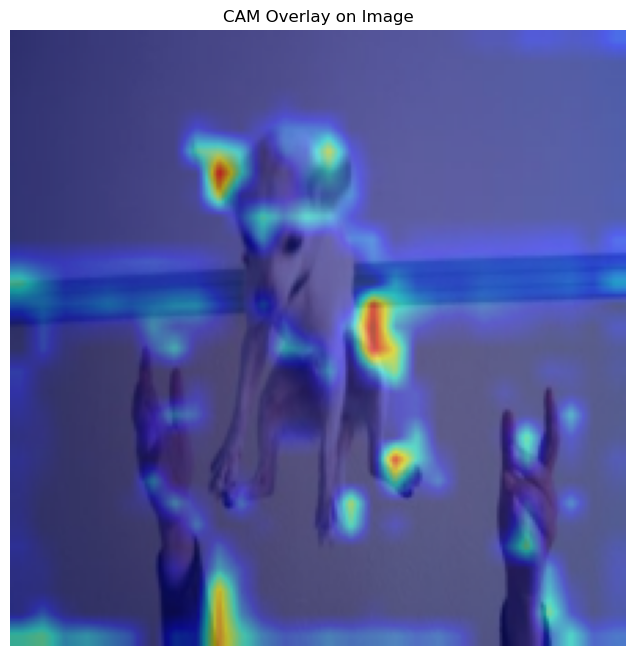

In [42]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer2")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

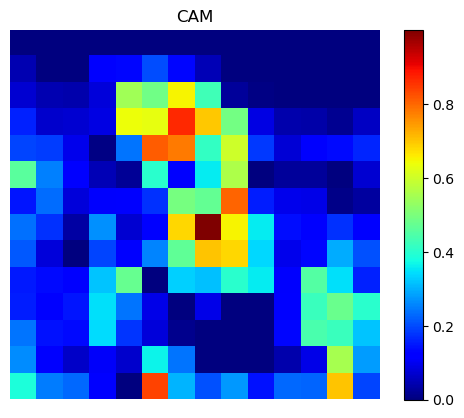

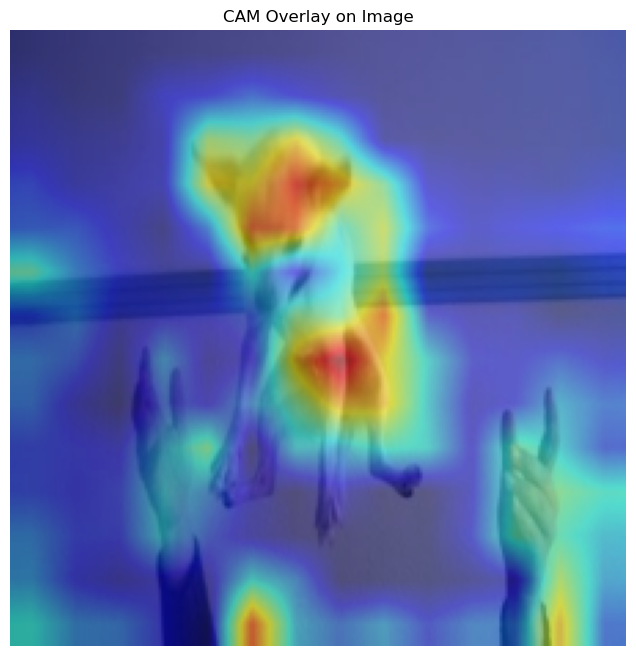

In [43]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer3")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

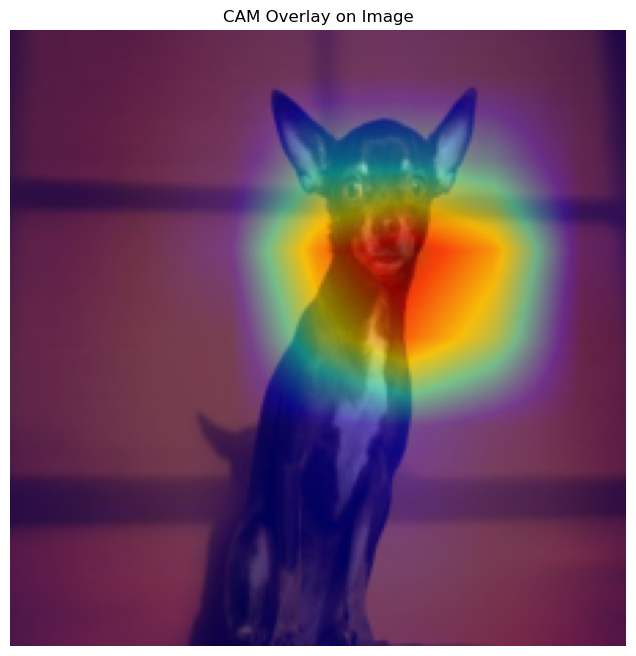

In [44]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

visualize_cam_on_image(grad_cam, orig_img)

In [45]:
def get_bbox(cam, threshold=0.01):
    coords = np.argwhere(cam > threshold)
    if coords.size == 0:
        return None
    # np.argwhere의 결과는 (row, col) 즉, (y, x) 순서입니다.
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [46]:
cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.5)

print(bbox)

(np.int64(79), np.int64(65), np.int64(150), np.int64(128))


In [47]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print("활성화된 영역이 없습니다.")
    return img_with_bbox

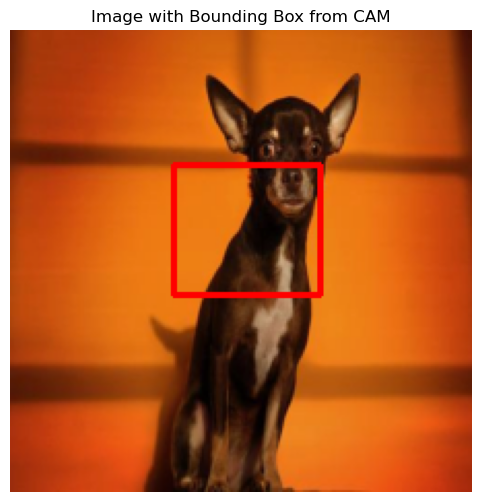

In [48]:
img_bbox = visualize_bbox_on_image(orig_img, bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Image with Bounding Box from CAM")
plt.axis("off")
plt.show()

In [49]:
ground_bbox

[78.848, 19.333333333333332, 169.792, 222.0]

In [50]:
def get_iou(bbox1, bbox2):
    # bbox 중 하나라도 None이면 IoU 0.0
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 두 bbox의 교집합 영역 좌표 계산
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합의 너비와 높이 (음수가 되지 않도록)
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 bbox의 면적 계산
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 면적: A ∪ B = A + B - A ∩ B
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou

In [51]:
get_iou(bbox, ground_bbox)

np.float64(0.24268476957479906)

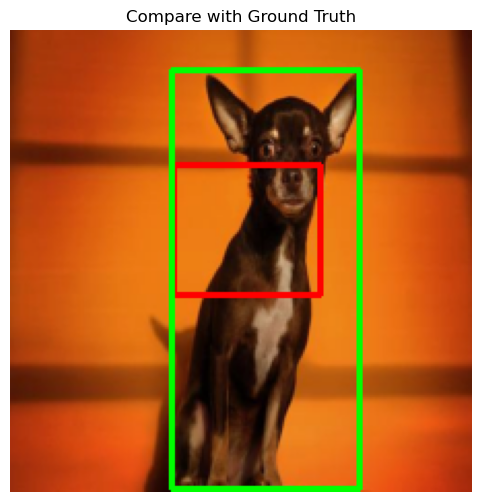

In [52]:
def visualize_both_bbox_on_image(img, bbox, ground_bbox, thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()

    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

In [54]:
def get_iou(gt_bbox, pred_bbox):
    # 두 박스 중 하나라도 없으면 IOU는 0
    if gt_bbox is None or pred_bbox is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = gt_bbox
    x_min2, y_min2, x_max2, y_max2 = pred_bbox

    # 교집합 영역 계산 (겹치는 부분의 좌표)
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합 너비/높이 → 음수가 나오면 0으로 처리
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 박스의 면적
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 = 각 영역 합 - 교집합
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    # 최종 IoU 계산
    iou = inter_area / union_area
    return iou

In [55]:
get_iou(ground_bbox, bbox)

np.float64(0.24268476957479906)

In [74]:
random_num = np.random.randint(0, len(valid_dataset))
print(random_num)
image, label, bbox = valid_dataset[random_num]
sample_valid_image = image.unsqueeze(0).to(device)

573


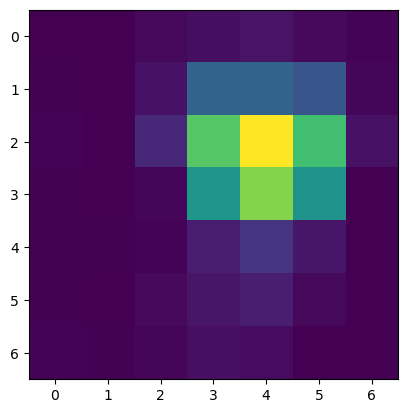

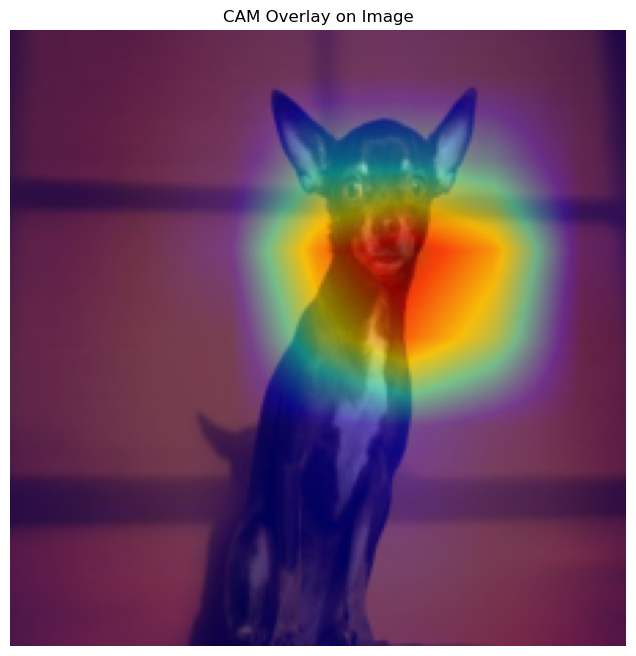

In [84]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")
plt.imshow(grad_cam)
visualize_cam_on_image(grad_cam, orig_img)

In [120]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

In [110]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [144]:
def visualize_both_bbox_on_image_c(img, bbox, ground_truth, thickness=2):
    # OpenCV 함수 오류를 방지하기 위해 배열이 메모리에 연속적으로 배치되도록 보장 (선택적 안정화)
    img_with_bbox = np.ascontiguousarray(img.copy())
    
    # 1. 예측 bbox 좌표를 모두 정수형(int)으로 변환
    x_min, y_min, x_max, y_max = map(int, bbox)
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)
    
    # 2. 정답(ground_truth) bbox 좌표도 모두 정수형(int)으로 변환
    x_min_t, y_min_t, x_max_t, y_max_t = map(int, ground_truth)
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)
    
    return img_with_bbox

757
7722
1701
1334
2910


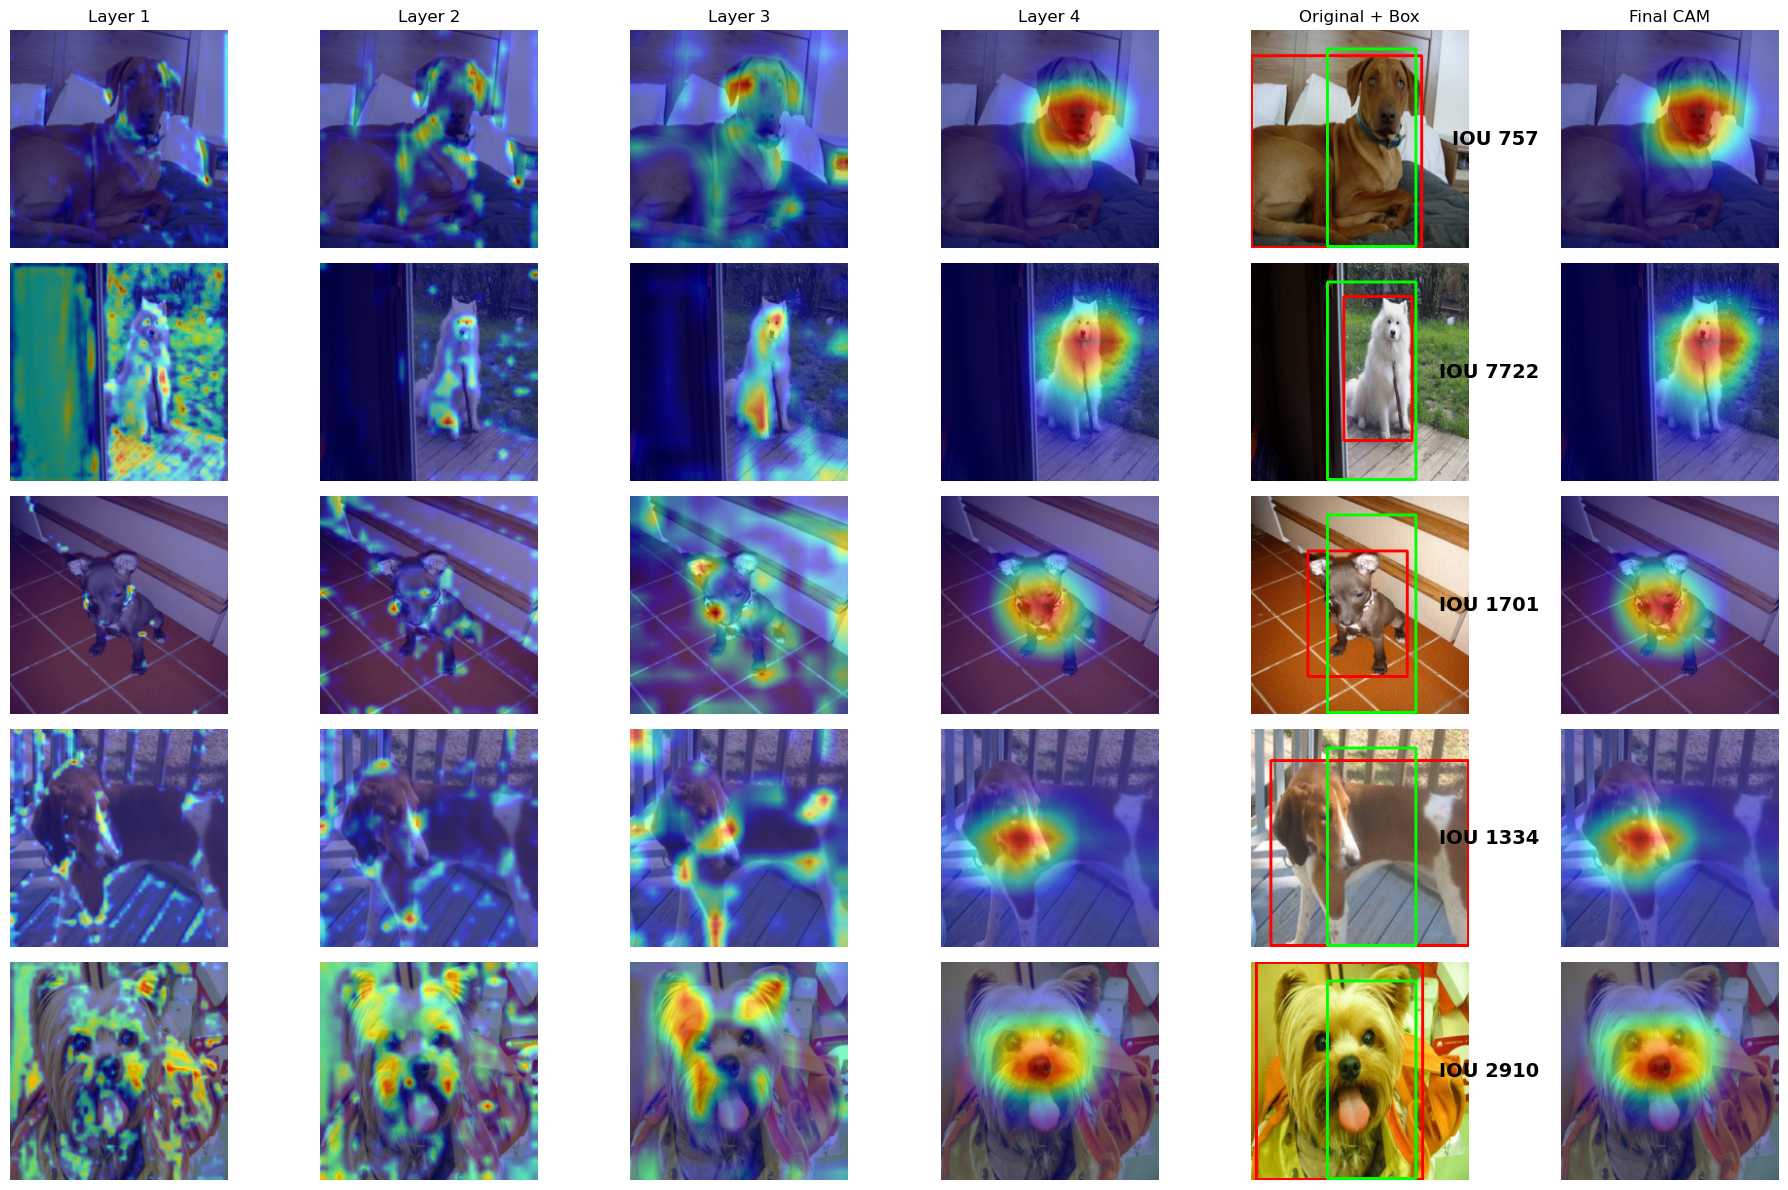

In [190]:
import matplotlib.pyplot as plt
import numpy as np

# 5행 6열 서브플롯 생성
# figsize는 인치 단위 (가로, 세로) - 화면에 맞게 조절하세요
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(18, 12))

import matplotlib.pyplot as plt
import numpy as np

alpha= 0.5
for r in range(5):
    # 1. 랜덤 이미지 로드
    random_num = np.random.randint(0, len(valid_dataset))
    image_0, label_0, bbox_0 = valid_dataset[0]
    image_0 = image_0.to(device)
    image_0 = image_0.unsqueeze(0).to(device) 
    # [C, H, W] -> [1, C, H, W]
    cam_c = generate_cam(model, image_0)
    print(random_num)
    for c in range(6):
        image_c, label_c, bbox_c = valid_dataset[random_num]
        
        # 1. 모델 입력용 4차원 텐서 준비
        image_tensor = image_c.unsqueeze(0).to(device) 
        
        # ---------------------------------------------------------
        # 2. [공통] 원본 이미지를 0~255 컬러 이미지(uint8)로 복원
        # ---------------------------------------------------------
        valid_image = image_c.cpu().squeeze().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        
        valid_image_unnorm = std * valid_image + mean
        valid_image_unnorm = np.clip(valid_image_unnorm, 0, 1)
        valid_image_uint8 = (valid_image_unnorm * 255).astype(np.uint8)

        # ---------------------------------------------------------
        # 3. 열(c)에 따라 다르게 처리 (c=4는 원본+박스 / 나머지는 CAM)
        # ---------------------------------------------------------
        if c == 4:
            # [4번째 열] 원본 이미지 그대로 복사 후 바운딩 박스 그리기
            overlay = valid_image_uint8.copy()
            # (주의: ground_bbox 변수가 미리 정의되어 있어야 합니다)
            overlay = visualize_both_bbox_on_image_c(overlay, bbox_c, ground_bbox)
            
        else:
            # [나머지 열] CAM 생성
            if c < 4:  # 0, 1, 2, 3 열 -> 각 Layer별 Grad-CAM
                layer_name = "layer" + str(c+1)
                cam_c = generate_grad_cam(model, image_tensor, target_layer_name=layer_name)
            elif c == 5: # 5 열 -> 최종 CAM
                cam_c = generate_cam(model, image_tensor)
                
            # CAM 리사이즈 및 히트맵 컬러 변환
            cam_resized = cv2.resize(cam_c, (valid_image_uint8.shape[1], valid_image_uint8.shape[0]))
            heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            
            # 원본 이미지와 히트맵 합성 (Alpha Blending)
            overlay = heatmap * alpha + valid_image_uint8 * (1 - alpha)
            overlay = overlay.astype(np.uint8)
            
            # (선택) CAM 위에도 박스를 그리고 싶다면 아래 주석을 해제하세요!
            # overlay = visualize_both_bbox_on_image_c(overlay, bbox_c, ground_bbox)

        # ---------------------------------------------------------
        # 4. 결과 출력 및 타이틀/축 설정
        # ---------------------------------------------------------
        axes[r, c].imshow(overlay) 
        axes[r, c].axis('off')
        
        # 첫 번째 행에 열(Column) 이름 표시
        if r == 0:
            titles = ["Layer 1", "Layer 2", "Layer 3", "Layer 4", "Original + Box", "Final CAM"]
            axes[r, c].set_title(titles[c])
            
    # 행 타이틀 추가 (for c 루프 바깥에 위치해야 정상 작동함)
    axes[r, 5].text(-0.1, 0.5, f"IOU {get_iou(bbox_c,)}", 
                    transform=axes[r, 5].transAxes, 
                    fontsize=14, fontweight='bold',
                    va='center', ha='right')

# 서브플롯 간 간격 자동 조절
plt.tight_layout()

# 그래프 표시
plt.show()

